In [ ]:
import pandas as pd

df1 = pd.read_csv("./offres_rekrute_mecanique.csv", encoding="utf-8-sig", sep=",", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("./offres_emploima.csv", encoding="utf-8-sig", sep=",", engine='python', on_bad_lines='skip')
df3 = pd.read_csv("./offres_dreamjob_mecanique.csv", encoding="utf-8-sig", sep=",", engine='python', on_bad_lines='skip')

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

df3.rename(columns={
    "Compétences Techniques": "Compétences techniques",
    "Soft Skills": "Soft skills",
    "Secteur" : "Secteur d'activité"
}, inplace=True)

ordre_logique = ["Titre du poste","Entreprise","Ville", "Secteur d'activité", "Contrat proposé", "Niveau d'étude",	
                 "Expérience",	"Compétences techniques", "Langues", "Soft skills", "Lien de l'offre" 	]

toutes_les_colonnes = list(set(df1.columns) | set(df2.columns) | set(df3.columns))
for col in toutes_les_colonnes:
    if col not in ordre_logique:
        ordre_logique.append(col)

df1_aligne = df1.reindex(columns=ordre_logique)
df2_aligne = df2.reindex(columns=ordre_logique)
df3_aligne = df3.reindex(columns=ordre_logique)

df_bis = pd.concat([df1_aligne, df2_aligne, df3_aligne], ignore_index=True)

df_bis = df_bis.astype(object)
df_bis.fillna("Non spécifié", inplace=True)

df_bis

,Titre du poste,Entreprise,Ville,Secteur d'activité,Contrat proposé,Niveau d'étude,Expérience,Compétences techniques,Langues,Soft skills,Lien de l'offre
0,Responsable SAV,Auto Hall,Casablanca,Automobile / Motos / Cycles,CDI,Bac +5,Junior (1 à 3 ans),Excel,Non spécifié,"Travail en équipe, innovation, initiative, fle...",https://www.rekrute.com/fr/offre-emploi-respon...
1,Ingénieur Installation Générale Senior,Capgemini Engineering,Casablanca,BTP / Génie Civil,CDI,Bac +5,Intermédiaire (3 à 5 ans),ERP,Anglais,"Communication, travailler en équipe, autonomie...",https://www.rekrute.com/fr/offre-emploi-ingeni...
2,Directeur Technique,Confidentiel,Marrakech,Hôtellerie / Restauration,CDI,Bac +5,Confirmé (5 à 10 ans),Non spécifié,"Français, Anglais, Arabe","Travail en équipe, rigueur, organisation, lead...",https://www.rekrute.com/fr/offre-emploi-direct...
3,Responsable Maintenance,Sedec,Témara,BTP / Génie Civil,CDI,Bac +5,Confirmé (5 à 10 ans),"GMAO, Automatisme",Non spécifié,"Organisation, leadership, gestion de projet, i...",https://www.rekrute.com/fr/offre-emploi-respon...
4,Facility Manager,Manpower Agences,Casablanca,Autres Industries,Intérim,Bac +5,Confirmé (5 à 10 ans),Excel,"Français, Anglais","Communication, rigueur, organisation, leadersh...",https://www.rekrute.com/fr/offre-emploi-facili...
...,...,...,...,...,...,...,...,...,...,...,...
1805,ADM Value agrandit ses équipes à Rabat: découv...,Non spécifié,Rabat,"Agroalimentaire, Automobile, Aéronautique, Con...",Stage,"Bac+2, bac+3, bac+5",2 ans,CATIA,"Français, Anglais",Communication,https://www.dreamjob.ma/emploi/adm-value-recru...
1806,Fondation Arrawaj recrute Plusieurs Profils (T...,Fondation Arrawaj,Non spécifié,"Agroalimentaire, Automobile, Aéronautique, Con...",Stage,"Bac+2, bac+3, bac+5",2 ans,CATIA,"Français, Anglais",Communication,https://www.dreamjob.ma/emploi/fondation-arraw...
1807,Société de Construction Routière recrute un Re...,Société de Construction Routière,Salé,"Agroalimentaire, Automobile, Aéronautique, Con...",Stage,"Bac+2, bac+3, bac+5",2 ans,CATIA,"Français, Anglais",Communication,https://www.dreamjob.ma/emploi/societe-de-cons...
1808,Université Euromed de Fès recrute 16 nouveaux ...,Université Euromed de Fès,Fès,"Agroalimentaire, Automobile, Aéronautique, Con...",Stage,"Bac+2, bac+3, bac+5",2 ans,CATIA,"Français, Anglais",Communication,https://www.dreamjob.ma/emploi/universite-euro...


In [34]:
import re

df_bis.drop_duplicates(subset=["Titre du poste", "Entreprise"], keep="first", inplace=True)
niveau = df_bis["Niveau d'étude"].str.extract(r'(Bac\s*\+\s*\d+)', expand=False)
df_bis["Niveau d'étude"] = niveau.fillna(df_bis["Niveau d'étude"])
df_bis = df_bis[~df_bis["Titre du poste"].str.lower().str.contains(
    "téléconseiller|télévendeur|chargé de clientèle|service client|recouvrement", na=False)]
df_bis["Ville"] = df_bis["Ville"].replace("Maroc", "Non spécifié")
df_bis["Ville"] = df_bis["Ville"].str.lower()
df_bis["Ville"] = df_bis["Ville"].str.capitalize()

nb_non_specifies = df_bis.eq("Non spécifié").sum(axis=1)
# Affichage de la répartition
print(nb_non_specifies.value_counts().sort_index())

def nettoyer_texte_experience(exp):
    if "non spécifié" in str(exp).lower() or pd.isna(exp):
        return "Non spécifié"
    
    texte = str(exp).lower()
    if "débutant" in texte or "-1" in texte:
        return "0 an"
    
    nombres = re.findall(r"\d+", texte)
    
    if len(nombres) == 2:
        return f"{nombres[0]} à {nombres[1]} ans"  
    elif len(nombres) == 1:
        return f"{nombres[0]} ans"                    
    return "Non spécifié"
df_bis["Expérience"] = df_bis["Expérience"].apply(nettoyer_texte_experience)

def experience_max(exp):
    nombres = re.findall(r"\d+", str(exp))
    if not nombres:
        return 0
    return max(map(int, nombres))

df_bis = df_bis[nb_non_specifies <= 3]
df_bis = df_bis[df_bis["Expérience"].apply(experience_max) <= 10]

# Nombre d'offres restantes
print("Nombre d'offres :", len(df_bis))

df_bis.to_csv("ws_merged.csv", index=False, encoding="utf-8-sig")
df_bis.head(20)



0     52
1    175
2    272
3    245
4    200
5    134
6     62
7     34
8     15
Name: count, dtype: int64
Nombre d'offres : 628


,Titre du poste,Entreprise,Ville,Secteur d'activité,Contrat proposé,Niveau d'étude,Expérience,Compétences techniques,Langues,Soft skills,Lien de l'offre
0,Responsable SAV,Auto Hall,Casablanca,Automobile / Motos / Cycles,CDI,Bac +5,1 à 3 ans,Excel,Non spécifié,"Travail en équipe, innovation, initiative, fle...",https://www.rekrute.com/fr/offre-emploi-respon...
1,Ingénieur Installation Générale Senior,Capgemini Engineering,Casablanca,BTP / Génie Civil,CDI,Bac +5,3 à 5 ans,ERP,Anglais,"Communication, travailler en équipe, autonomie...",https://www.rekrute.com/fr/offre-emploi-ingeni...
2,Directeur Technique,Confidentiel,Marrakech,Hôtellerie / Restauration,CDI,Bac +5,5 à 10 ans,Non spécifié,"Français, Anglais, Arabe","Travail en équipe, rigueur, organisation, lead...",https://www.rekrute.com/fr/offre-emploi-direct...
3,Responsable Maintenance,Sedec,Témara,BTP / Génie Civil,CDI,Bac +5,5 à 10 ans,"GMAO, Automatisme",Non spécifié,"Organisation, leadership, gestion de projet, i...",https://www.rekrute.com/fr/offre-emploi-respon...
4,Facility Manager,Manpower Agences,Casablanca,Autres Industries,Intérim,Bac +5,5 à 10 ans,Excel,"Français, Anglais","Communication, rigueur, organisation, leadersh...",https://www.rekrute.com/fr/offre-emploi-facili...
5,Technicien centrale chaufferie,Confidentiel,Casablanca,Agroalimentaire,Non spécifié,Bac +2,0 an,Automatisme,Non spécifié,Non spécifié,https://www.rekrute.com/fr/offre-emploi-techni...
6,Préparateur Maintenance – Maintenance Fixe,Aya Gold & Silver,Taliouine- askaoune,Extraction / Mines,CDI,Bac +2,3 à 5 ans,"GMAO, ERP, Excel","Français, Anglais","Rigueur, organisation, relationnel",https://www.rekrute.com/fr/offre-emploi-prepar...
7,Technicien(ne) supérieur(e) - Secteur Hydrauli...,Manpower Agences,Casablanca,Energie,Non spécifié,Bac +3,1 à 3 ans,"ERP, Excel","Français, Anglais","Rigueur, organisation, innovation, adaptabilité",https://www.rekrute.com/fr/offre-emploi-techni...
8,TECHNICIEN DE FABRICATION,Cosumar,Kénitra,Agroalimentaire,Non spécifié,Bac +3,0 an,Non spécifié,Non spécifié,"Travail en équipe, rigueur, organisation, inno...",https://www.rekrute.com/fr/offre-emploi-techni...
9,Dessinateur projeteur,Confidentiel,Casablanca,Conseil / Etudes,CDI,Bac +2,1 à 3 ans,ERP,Non spécifié,"Communication, travail en équipe, autonomie, r...",https://www.rekrute.com/fr/offre-emploi-dessin...


In [35]:
import sqlite3
import pandas as pd

connection = sqlite3.connect("marche_emploi_mecanique.db")
df_bis.to_sql("offres", connection, if_exists="replace", index=False)
df = pd.read_sql("SELECT * FROM offres", connection)
print(df.head())


                           Titre du poste             Entreprise       Ville  \
0                         Responsable SAV              Auto Hall  Casablanca   
1  Ingénieur Installation Générale Senior  Capgemini Engineering  Casablanca   
2                     Directeur Technique           Confidentiel   Marrakech   
3                 Responsable Maintenance                  Sedec      Témara   
4                        Facility Manager       Manpower Agences  Casablanca   

            Secteur d'activité Contrat proposé Niveau d'étude  Expérience  \
0  Automobile / Motos / Cycles             CDI         Bac +5   1 à 3 ans   
1            BTP / Génie Civil             CDI         Bac +5   3 à 5 ans   
2    Hôtellerie / Restauration             CDI         Bac +5  5 à 10 ans   
3            BTP / Génie Civil             CDI         Bac +5  5 à 10 ans   
4            Autres Industries         Intérim         Bac +5  5 à 10 ans   

  Compétences techniques                   Langues  \
0 

In [36]:
df = pd.read_sql_query("""
SELECT *
FROM offres
WHERE Ville = 'Casablanca';
""", connection)

df.head()

,Titre du poste,Entreprise,Ville,Secteur d'activité,Contrat proposé,Niveau d'étude,Expérience,Compétences techniques,Langues,Soft skills,Lien de l'offre
0,Responsable SAV,Auto Hall,Casablanca,Automobile / Motos / Cycles,CDI,Bac +5,1 à 3 ans,Excel,Non spécifié,"Travail en équipe, innovation, initiative, fle...",https://www.rekrute.com/fr/offre-emploi-respon...
1,Ingénieur Installation Générale Senior,Capgemini Engineering,Casablanca,BTP / Génie Civil,CDI,Bac +5,3 à 5 ans,ERP,Anglais,"Communication, travailler en équipe, autonomie...",https://www.rekrute.com/fr/offre-emploi-ingeni...
2,Facility Manager,Manpower Agences,Casablanca,Autres Industries,Intérim,Bac +5,5 à 10 ans,Excel,"Français, Anglais","Communication, rigueur, organisation, leadersh...",https://www.rekrute.com/fr/offre-emploi-facili...
3,Technicien centrale chaufferie,Confidentiel,Casablanca,Agroalimentaire,Non spécifié,Bac +2,0 an,Automatisme,Non spécifié,Non spécifié,https://www.rekrute.com/fr/offre-emploi-techni...
4,Technicien(ne) supérieur(e) - Secteur Hydrauli...,Manpower Agences,Casablanca,Energie,Non spécifié,Bac +3,1 à 3 ans,"ERP, Excel","Français, Anglais","Rigueur, organisation, innovation, adaptabilité",https://www.rekrute.com/fr/offre-emploi-techni...


In [37]:
df = pd.read_sql_query("""
SELECT Ville, COUNT(*) AS Nombre
FROM offres
GROUP BY Ville
ORDER BY Nombre DESC;
""", connection)

df

,Ville,Nombre
0,Casablanca,229
1,Non spécifié,112
2,Tanger,93
3,Kénitra,54
4,Salé,16
5,Rabat,16
6,Marrakech,12
7,Berrechid,12
8,Mohammedia,10
9,Nouaceur,9


In [38]:
connection.close()

Ville
Casablanca             229
Non spécifié           112
Tanger                  93
Kénitra                 54
Rabat                   16
Salé                    16
Marrakech               12
Berrechid               12
Mohammedia              10
Nouaceur                 9
Jorf lasfar              8
El jadida                7
Tétouan                  6
Fès                      6
Agadir                   5
Meknès                   3
Nador                    3
Oujda                    3
Bouskoura                3
Oued zem                 3
Taroudant                2
Had soualem              2
Ouarzazate               2
Youssoufia               2
Témara                   1
Taliouine- askaoune      1
Mohammédia               1
Taliouine - askaoun      1
Benguerir                1
Berkane                  1
Dar bouazza              1
Larache                  1
Tit mellil               1
Skhirat                  1
Name: count, dtype: int64


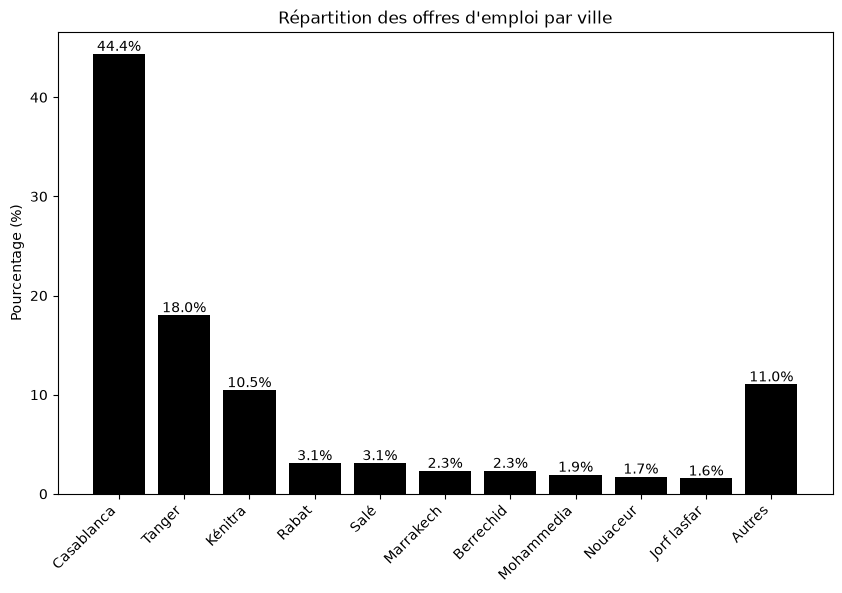

In [15]:
import matplotlib.pyplot as plt
print(df_bis["Ville"].value_counts())

villes_nettoyees = df_bis["Ville"].astype(str).str.strip()
villes_nettoyees = villes_nettoyees[villes_nettoyees != "Non spécifié"]
compte_villes = villes_nettoyees.value_counts()
pourcentages = (compte_villes / compte_villes.sum()) * 100
top = 10
top_villes = pourcentages.head(top).copy()
autres = pourcentages.iloc[top:].sum()

if autres > 0:
    top_villes["Autres"] = autres

plt.figure(figsize=(10, 6))
plt.bar(top_villes.index, top_villes.values, color="black")
plt.ylabel("Pourcentage (%)")
plt.title("Répartition des offres d'emploi par ville")
plt.xticks(rotation=45, ha="right")

for i in range(len(top_villes)):
    valeur = top_villes.values[i]
    plt.text(i, valeur + 0.3, str(round(valeur, 1)) + "%", ha="center")
plt.show()

In [16]:
! pip install streamlit

   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.3 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/10.3 MB 1.4 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/10.3 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/10.3 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/10.3 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/10.3 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.3 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.3 MB 1.1 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/10.3 MB 1.0 MB/s eta 0:00:08
   ---------- ----------------------------- 2.6/10.3 MB 1.1 MB/s eta 0:00:08
   ----------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
